In [1]:
# This runs all the ablation studies in series and saves the models as pk files in the `partial_models` folder.
# NOTE that this will require SOME DAYS to run. Be careful and patient. Or simply trust us that the results are correct and skip to the next cell.
# ! nohup bash -c "python drop_structure.py && python drop_position.py && python drop_mlc.py && python drop_conservation.py" > output.log 2>&1 &

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk


import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../../"), os.pardir)))
from customFunctions.utils import binary_auROC

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, PrecisionRecallDisplay
from scipy import stats

In [3]:
mithril_features = pd.read_csv("../../checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


In [4]:
embedding = pd.read_csv("../../data/Mithril_msm_embedding.csv", index_col=0)
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [5]:
mithril_features.columns

Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', 'ddG',
       'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
       'conservation_blocks', 'PWM_score', 'Human_MSA_position', 'bulge',
       'stem', 'hairpin', 'loop', 'unpaired_frequency', 'closest_modification',
       'closest_modification_2D', 'OEUF_score'],
      dtype='object')

In [6]:
X = mithril_features.join(embedding)
X.shape

(4521, 788)

In [7]:
y_test = pd.read_csv("../../data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])
X_test = X.loc[y_test.index]
X_test

/tmp/ipykernel_803405/3679153987.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = pd.read_csv("../../data/test_set.txt", sep="\t", index_col="Mithril_id").label\


,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1846,1.000,3.707,0.510351,0.028169,1.1,0.942350,0.022173,1.000000,0.408534,14.0,...,0.670284,-0.187625,-0.493014,-0.333382,0.179401,0.408108,-0.683268,-0.737266,0.498617,-1.002428
MITHRIL.4929,0.996,0.980,0.327147,0.000000,0.0,0.817638,0.115845,0.991111,0.922203,5.0,...,0.379588,0.354751,0.390387,-0.997868,-0.110256,0.919109,-0.859502,0.172431,0.486186,-0.654698
MITHRIL.9729,1.000,5.826,0.850926,0.000000,-0.3,0.992614,0.000000,1.000000,0.066377,10.0,...,-0.425040,0.140006,-0.648723,-0.194253,0.805011,0.380403,-0.498180,0.813303,-1.425700,0.438128
MITHRIL.9728,1.000,5.826,0.850926,0.000000,-1.2,0.992614,0.006647,1.000000,0.066377,10.0,...,-0.178584,0.298345,-0.759088,0.083235,1.046968,0.318218,-0.465996,0.723391,-1.183443,0.407064
MITHRIL.9752,0.456,0.908,0.797513,0.000000,0.0,0.739008,0.035547,0.789513,1.215301,9.0,...,-0.057042,0.741527,-0.704968,-0.290943,0.564526,-0.091588,-0.721032,0.827592,-0.592988,0.011270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.17470,0.000,-0.238,0.312028,0.000000,2.2,0.262963,0.689630,1.000000,1.128278,0.0,...,0.171333,0.873823,-0.128143,0.210718,-0.723211,1.073902,-0.699213,-0.288812,-0.098388,-0.583400
MITHRIL.17540,0.000,0.876,0.656165,0.000000,0.0,0.859806,0.014914,0.993333,0.753068,2.0,...,0.339020,0.419849,-0.422917,-0.410678,-0.192811,0.509847,-0.800014,-0.705664,1.058065,-0.595274
MITHRIL.30284,0.000,-0.125,0.338614,0.000000,0.0,0.858940,0.024259,0.824444,0.884878,3.0,...,-0.495467,0.495154,0.294965,-0.449407,0.286263,-0.445074,-0.055157,-0.037730,-0.095185,-0.331934


In [8]:
# only following models are currentely ready:
# model_no_structure
# model_no_position
# model_no_mlc
# model_no_rnamsm

In [9]:
model_full = pk.load(open("../../checkpoints/candidate_models/model_svc.pk", "rb"))
model_full

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x717e21f02160>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x717e228893a0>, verbose=2)

In [10]:
model_no_structure = pk.load(open("./partial_models/model_svc_no_structure.pk", "rb"))
model_no_structure

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ref_frequency',
       '...
                                                                       scoring_function=<function roc_auc_score at 0x717e21f02160>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x717e228893a0>, verbose=2)

In [11]:
model_no_position = pk.load(open("./partial_models/model_svc_no_position.pk", "rb"))
model_no_position

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x717e21f02160>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x717e228893a0>, verbose=2)

In [12]:
model_no_mlc = pk.load(open("./partial_models/model_svc_no_mlc.pk", "rb"))
model_no_mlc

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'ss_distorsion', 'ddG',
       'ref_fr...
                                                                       scoring_function=<function roc_auc_score at 0x717e21f02160>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x717e228893a0>, verbose=2)

In [13]:
model_no_rnamsm = pk.load(open("./partial_models/model_svc_no_rnamsm.pk", "rb"))
model_no_rnamsm

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                           random_state=777),
                                                          threshold=0.01)),
                                       ('scaler', StandardScalerDF()),
                                       ('gridsearch',
                                        GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimato...
                                                                                                           oob_score=True,
                                                                                                           replacement=True,
                                                                                                           sampling_strategy='not '
                                                                                                                             'minority'),
                                                                       n_jobs=8,
                                                                       param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x717e20a44d60>,
                                                                       scoring_function=<function roc_auc_score at 0x717e21f02160>))]),
             n_jobs=1,
             param_grid={'feature_selection__threshold': [0.01, 0.02, 0.03,
                                                          0.05]},
             scoring=<function binary_auROC at 0x717e228893a0>, verbose=2)

In [14]:
model_no_conservation = pk.load(open("./partial_models/model_svc_no_conservation.pk", "rb"))
model_no_conservation

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['MLC_score', 'ss_distorsion', 'ddG', 'Human_MSA_position', 'bulg...
                                                                       scoring_function=<function roc_auc_score at 0x717e21f02160>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x717e228893a0>, verbose=2)

In [15]:
model_full.best_score_, model_no_mlc.best_score_, model_no_position.best_score_, model_no_structure.best_score_, model_no_rnamsm.best_score_, model_no_conservation.best_score_

(0.831520979020979,
 0.8129795204795205,
 0.8339360639360638,
 0.8234440559440559,
 0.8162912087912089,
 0.8211263736263735)

In [16]:
cv_scores = pd.DataFrame(model_full.cv_results_).loc[model_full.best_index_, ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score']].astype(float)
cv_scores, cv_scores.mean()

(split0_test_score    0.796104
 split1_test_score    0.885714
 split2_test_score    0.711538
 split3_test_score    0.836538
 split4_test_score    0.800000
 split5_test_score    0.851748
 split6_test_score    0.834965
 split7_test_score    0.895105
 split8_test_score    0.794406
 split9_test_score    0.909091
 Name: 105, dtype: float64,
 0.831520979020979)

In [17]:
cv_scores_no_position = pd.DataFrame(model_no_position.cv_results_).loc[model_no_position.best_index_, ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score']].astype(float)
cv_scores_no_position, cv_scores_no_position.mean()

(split0_test_score    0.814286
 split1_test_score    0.875325
 split2_test_score    0.674451
 split3_test_score    0.820055
 split4_test_score    0.808392
 split5_test_score    0.876923
 split6_test_score    0.839161
 split7_test_score    0.895105
 split8_test_score    0.808392
 split9_test_score    0.927273
 Name: 86, dtype: float64,
 0.8339360639360638)

In [18]:
cv_scores_no_mlc = pd.DataFrame(model_no_mlc.cv_results_).loc[model_no_mlc.best_index_, ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score']].astype(float)
cv_scores_no_mlc, cv_scores_no_mlc.mean()

(split0_test_score    0.768831
 split1_test_score    0.877922
 split2_test_score    0.679945
 split3_test_score    0.829670
 split4_test_score    0.776224
 split5_test_score    0.840559
 split6_test_score    0.833566
 split7_test_score    0.841958
 split8_test_score    0.746853
 split9_test_score    0.934266
 Name: 74, dtype: float64,
 0.8129795204795205)

In [19]:
cv_scores_no_rnamsm = pd.DataFrame(model_no_rnamsm.cv_results_).loc[model_no_rnamsm.best_index_, ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score']].astype(float)
cv_scores_no_rnamsm, cv_scores_no_rnamsm.mean()

(split0_test_score    0.793506
 split1_test_score    0.866234
 split2_test_score    0.717033
 split3_test_score    0.762363
 split4_test_score    0.765035
 split5_test_score    0.855944
 split6_test_score    0.833566
 split7_test_score    0.868531
 split8_test_score    0.784615
 split9_test_score    0.916084
 Name: 0, dtype: float64,
 0.8162912087912089)

In [20]:
cv_scores_no_structure = pd.DataFrame(model_no_structure.cv_results_).loc[model_no_structure.best_index_, ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score']].astype(float)
cv_scores_no_structure, cv_scores_no_structure.mean()

(split0_test_score    0.733766
 split1_test_score    0.877922
 split2_test_score    0.711538
 split3_test_score    0.806319
 split4_test_score    0.794406
 split5_test_score    0.847552
 split6_test_score    0.857343
 split7_test_score    0.893706
 split8_test_score    0.790210
 split9_test_score    0.921678
 Name: 159, dtype: float64,
 0.8234440559440559)

In [21]:
cv_scores_no_conservation = pd.DataFrame(model_no_conservation.cv_results_).loc[model_no_conservation.best_index_, ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score']].astype(float)
cv_scores_no_conservation, cv_scores_no_conservation.mean()

(split0_test_score    0.763636
 split1_test_score    0.876623
 split2_test_score    0.762363
 split3_test_score    0.832418
 split4_test_score    0.770629
 split5_test_score    0.848951
 split6_test_score    0.833566
 split7_test_score    0.858741
 split8_test_score    0.840559
 split9_test_score    0.823776
 Name: 75, dtype: float64,
 0.8211263736263735)

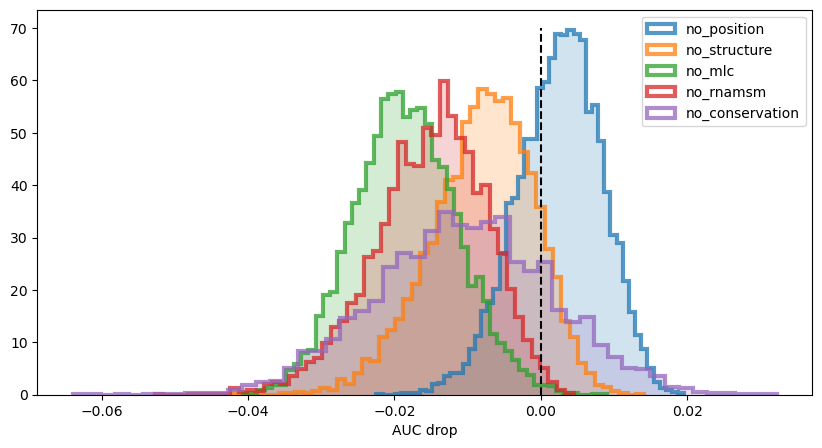

In [45]:
plt.figure(figsize=(10,5))
i = 0
for aucs, label in zip(
    [cv_scores_no_position, cv_scores_no_structure, cv_scores_no_mlc, cv_scores_no_rnamsm, cv_scores_no_conservation],
    ["no_position", "no_structure", "no_mlc", "no_rnamsm", "no_conservation"]
):
    auc_drops = aucs - cv_scores
    plt.hist(
        auc_drops.sample(len(auc_drops)*10_000, replace=True, random_state=42).values.reshape(-1, 10_000).mean(axis=0),
        50, histtype="step", lw=3, alpha=.75, density=True, color=f"C{i}", label=label
    )
    plt.hist(
        auc_drops.sample(len(auc_drops)*10_000, replace=True, random_state=42).values.reshape(-1, 10_000).mean(axis=0),
        50, histtype="bar", alpha=.2, density=True, color=f"C{i}"
    )
    i+=1
plt.plot([0,0], [0, 70], "k--")
plt.legend()
plt.xlabel("AUC drop")
plt.savefig("../../../figures/svg/ablation_study_tAPOGEE_training_cv.svg")
plt.show()

In [24]:
pd.Index(model_full.feature_names_in_).difference(model_no_structure.feature_names_in_)

Index(['bulge', 'ddG', 'hairpin', 'loop', 'ss_distorsion', 'stem',
       'unpaired_frequency'],
      dtype='object')

In [25]:
pd.Index(model_full.feature_names_in_).difference(model_no_position.feature_names_in_)

Index(['Human_MSA_position', 'closest_modification',
       'closest_modification_2D'],
      dtype='object')

In [26]:
pd.Index(model_full.feature_names_in_).difference(model_no_mlc.feature_names_in_)

Index(['MLC_score', 'OEUF_score'], dtype='object')

In [27]:
pd.Index(model_full.feature_names_in_).difference(model_no_rnamsm.feature_names_in_)

Index(['channel_0', 'channel_1', 'channel_10', 'channel_100', 'channel_101',
       'channel_102', 'channel_103', 'channel_104', 'channel_105',
       'channel_106',
       ...
       'channel_90', 'channel_91', 'channel_92', 'channel_93', 'channel_94',
       'channel_95', 'channel_96', 'channel_97', 'channel_98', 'channel_99'],
      dtype='object', length=768)

In [28]:
pd.Index(model_full.feature_names_in_).difference(model_no_conservation.feature_names_in_)

Index(['PWM_score', 'PhastCons_100V', 'PhyloP_100V', 'alt_frequency',
       'conservation_blocks', 'coverage', 'entropy', 'ref_frequency',
       'unpaired_frequency'],
      dtype='object')

In [29]:
y_predictions = model_full.predict_proba(X_test)[:,1]
y_predictions

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.732345  , 0.50320941, 0.69621731, 0.75262256, 0.63744024,
       0.85793906, 0.83934362, 0.68666986, 0.77400988, 0.72928139,
       0.43149472, 0.49104377, 0.57234013, 0.68608416, 0.84613389,
       0.85932213, 0.67258135, 0.52321361, 0.78577154, 0.65718654,
       0.65356851, 0.32980989, 0.60906257, 0.55958534, 0.82106849,
       0.62526668, 0.18718495, 0.5829429 , 0.76037577, 0.79850086,
       0.496178  , 0.68339485, 0.82327001, 0.85963202, 0.17816114,
       0.64541683, 0.47488039, 0.63257534, 0.38715892, 0.29299348,
       0.14235268, 0.19186285, 0.17663704, 0.29799949, 0.20519218,
       0.30766514, 0.11442608, 0.21699814, 0.21413417, 0.22410011,
       0.29971474, 0.15084541, 0.21249193, 0.34205214, 0.10251551,
       0.31188194, 0.14414843, 0.37413483, 0.24597761, 0.23244546,
       0.1147713 , 0.1079891 , 0.54830819, 0.23050929, 0.3294386 ,
       0.22931932, 0.36613684, 0.28403307, 0.18876302, 0.27703376,
       0.6982887 ])

In [30]:
y_predictions_no_structure = model_no_structure.predict_proba(X_test)[:,1]
y_predictions_no_structure

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.7773983 , 0.67204025, 0.81834816, 0.9110861 , 0.51643688,
       0.86048522, 0.88577659, 0.73181373, 0.80509092, 0.77344101,
       0.47871317, 0.34170159, 0.43852543, 0.64924205, 0.87367255,
       0.86471875, 0.83302472, 0.26218979, 0.8672593 , 0.57055887,
       0.73778598, 0.21229457, 0.49716298, 0.48077548, 0.85432245,
       0.7451515 , 0.13526827, 0.50800156, 0.84685568, 0.86362704,
       0.4383947 , 0.77172771, 0.86749591, 0.86179769, 0.13036503,
       0.63039633, 0.51439039, 0.63198694, 0.40695581, 0.18011114,
       0.10845759, 0.15643012, 0.32854305, 0.21504301, 0.08931616,
       0.12915419, 0.09569466, 0.14481491, 0.16659682, 0.24396515,
       0.32683071, 0.06774081, 0.11291724, 0.25712775, 0.06286377,
       0.28433821, 0.16055401, 0.30511384, 0.2829644 , 0.18641906,
       0.09448371, 0.0914662 , 0.72928269, 0.31095373, 0.26147966,
       0.2280208 , 0.26279035, 0.35977042, 0.14439577, 0.32111112,
       0.80876977])

In [31]:
y_predictions_no_position = model_no_position.predict_proba(X_test)[:,1]
y_predictions_no_position

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.76638715, 0.51332534, 0.70186502, 0.72842596, 0.62604174,
       0.8389855 , 0.86260331, 0.6983152 , 0.76500619, 0.8005801 ,
       0.51532258, 0.51925946, 0.54848189, 0.76726368, 0.84175279,
       0.88822888, 0.71131942, 0.41101831, 0.80773647, 0.61889322,
       0.7420247 , 0.3240969 , 0.67348054, 0.56935309, 0.85387737,
       0.66866653, 0.15506889, 0.61006506, 0.80059856, 0.81462253,
       0.47307248, 0.73668581, 0.85508348, 0.8641483 , 0.17626213,
       0.73414754, 0.31733707, 0.58631181, 0.4146311 , 0.29808123,
       0.1157159 , 0.14692521, 0.15100626, 0.37712711, 0.19446173,
       0.43861743, 0.08609301, 0.16467874, 0.16169261, 0.19599011,
       0.27623314, 0.15155409, 0.16593504, 0.30920171, 0.08713111,
       0.31755952, 0.12266488, 0.32444449, 0.29016379, 0.23673791,
       0.08027786, 0.05780459, 0.63107825, 0.25116576, 0.20242206,
       0.22140903, 0.32243942, 0.25950378, 0.14251245, 0.27913837,
       0.77401126])

In [32]:
y_predictions_no_mlc = model_no_mlc.predict_proba(X_test)[:,1]
y_predictions_no_mlc

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.70164281, 0.56522854, 0.59952997, 0.70049725, 0.46798867,
       0.8113115 , 0.75871369, 0.57645537, 0.64222936, 0.65176906,
       0.39333861, 0.36701362, 0.50271784, 0.54290521, 0.81744686,
       0.79408411, 0.7052732 , 0.4763192 , 0.73239918, 0.5213324 ,
       0.63064153, 0.21004921, 0.42509539, 0.42244072, 0.79419025,
       0.64029355, 0.20862113, 0.5471831 , 0.79573161, 0.7939726 ,
       0.48763234, 0.73481389, 0.80693234, 0.81421602, 0.2292221 ,
       0.59623591, 0.63045354, 0.60821636, 0.32316349, 0.30979409,
       0.20529601, 0.20448483, 0.30911443, 0.25314865, 0.18978257,
       0.29715772, 0.14993326, 0.37097459, 0.25899987, 0.25770955,
       0.24585075, 0.15475607, 0.28481495, 0.40828601, 0.1363135 ,
       0.28883384, 0.2205894 , 0.41756195, 0.34967027, 0.29397009,
       0.1767502 , 0.19995164, 0.60907117, 0.37613123, 0.3729757 ,
       0.18613496, 0.29135759, 0.23164064, 0.19834917, 0.31025856,
       0.78303719])

In [33]:
y_predictions_no_rnamsm = model_no_rnamsm.predict_proba(mithril_features.loc[y_test.index])[:,1]
y_predictions_no_rnamsm

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.7175173 , 0.37062445, 0.57112199, 0.7343983 , 0.74823044,
       0.86836479, 0.80793318, 0.68404837, 0.73646346, 0.84521748,
       0.7262843 , 0.5727781 , 0.67397194, 0.66910367, 0.84830633,
       0.84942808, 0.68984569, 0.75107294, 0.87590658, 0.78182355,
       0.58384135, 0.2410619 , 0.50379443, 0.52763459, 0.81656925,
       0.74845727, 0.19877132, 0.6041904 , 0.71012265, 0.67447025,
       0.55425005, 0.64584138, 0.8287366 , 0.85728   , 0.13252123,
       0.73108442, 0.59460215, 0.65979712, 0.41452025, 0.19573458,
       0.09438761, 0.18421489, 0.13141518, 0.21590166, 0.15545073,
       0.22107457, 0.08141212, 0.20881394, 0.1208411 , 0.20279194,
       0.37569725, 0.08836753, 0.20034146, 0.33677087, 0.03588785,
       0.23446612, 0.09827029, 0.23010271, 0.0587089 , 0.45367831,
       0.04444854, 0.08705147, 0.27177018, 0.05009927, 0.25767354,
       0.33254096, 0.23904658, 0.32057049, 0.19456079, 0.45457756,
       0.54913952])

In [35]:
y_predictions_no_conservation = model_no_conservation.predict_proba(X_test)[:,1]
y_predictions_no_conservation

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.56550396, 0.42512852, 0.58594969, 0.60296866, 0.58849409,
       0.77442394, 0.72518703, 0.58826708, 0.56049282, 0.64084763,
       0.43537802, 0.4950188 , 0.54482363, 0.54574403, 0.74689347,
       0.73203631, 0.56995315, 0.64213642, 0.70680693, 0.69394426,
       0.63406442, 0.45943767, 0.40896253, 0.36631169, 0.75731136,
       0.7032881 , 0.40812603, 0.46444923, 0.65425274, 0.75841695,
       0.5538318 , 0.70525967, 0.76615286, 0.70077408, 0.33954032,
       0.65113751, 0.37629113, 0.6496334 , 0.32585403, 0.50693447,
       0.22573484, 0.38097275, 0.39797699, 0.46798186, 0.25435067,
       0.31449438, 0.31523052, 0.36505201, 0.34563167, 0.35464462,
       0.50341276, 0.22761244, 0.41235191, 0.32125053, 0.19921395,
       0.43512963, 0.21222813, 0.60387891, 0.41395959, 0.26916457,
       0.18801892, 0.25067866, 0.64956235, 0.3937497 , 0.39802983,
       0.33660489, 0.50249338, 0.40338483, 0.23556339, 0.40673166,
       0.64693035])

In [36]:
(
    (roc_auc_score(y_test, y_predictions), roc_auc_score(y_test, y_predictions_no_structure)),
    (average_precision_score(y_test, y_predictions), average_precision_score(y_test, y_predictions_no_structure)),
)

((0.9338118022328549, 0.9090909090909091),
 (0.9482013541948461, 0.9271681806116844))

In [37]:
(
    (roc_auc_score(y_test, y_predictions), roc_auc_score(y_test, y_predictions_no_position)),
    (average_precision_score(y_test, y_predictions), average_precision_score(y_test, y_predictions_no_position)),
)

((0.9338118022328549, 0.9258373205741627),
 (0.9482013541948461, 0.9343225484603309))

In [38]:
(
    (roc_auc_score(y_test, y_predictions), roc_auc_score(y_test, y_predictions_no_mlc)),
    (average_precision_score(y_test, y_predictions), average_precision_score(y_test, y_predictions_no_mlc)),
)

((0.9338118022328549, 0.9059011164274321),
 (0.9482013541948461, 0.9162305390859502))

In [39]:
(
    (roc_auc_score(y_test, y_predictions), roc_auc_score(y_test, y_predictions_no_rnamsm)),
    (average_precision_score(y_test, y_predictions), average_precision_score(y_test, y_predictions_no_rnamsm)),
)

((0.9338118022328549, 0.9545454545454546),
 (0.9482013541948461, 0.9712022660114595))

In [40]:
(
    (roc_auc_score(y_test, y_predictions), roc_auc_score(y_test, y_predictions_no_conservation)),
    (average_precision_score(y_test, y_predictions), average_precision_score(y_test, y_predictions_no_conservation)),
)

((0.9338118022328549, 0.886762360446571),
 (0.9482013541948461, 0.900687406798924))

In [115]:
auc_drop_training_and_test = pd.DataFrame(
    [
        [cv_scores.mean(), roc_auc_score(y_test, y_predictions)],
        [cv_scores_no_position.mean(), roc_auc_score(y_test, y_predictions_no_position)],
        [cv_scores_no_structure.mean(), roc_auc_score(y_test, y_predictions_no_structure)],
        [cv_scores_no_mlc.mean(), roc_auc_score(y_test, y_predictions_no_mlc)],
        [cv_scores_no_rnamsm.mean(), roc_auc_score(y_test, y_predictions_no_rnamsm)],
        [cv_scores_no_conservation.mean(), roc_auc_score(y_test, y_predictions_no_conservation)],
    ],
    index=[
        "full_model",
        "no_position",
        "no_structure",
        "no_mlc",
        "no_rnamsm",
        "no_conservation",
    ],
    columns=["training", "test"]
)
auc_drop_training_and_test = auc_drop_training_and_test - auc_drop_training_and_test.loc["full_model"]
auc_drop_training_and_test.drop("full_model", axis=0, inplace=True)
auc_drop_training_and_test

,training,test
no_position,0.002415,-0.007974
no_structure,-0.008077,-0.024721
no_mlc,-0.018541,-0.027911
no_rnamsm,-0.015230,0.020734
no_conservation,-0.010395,-0.047049


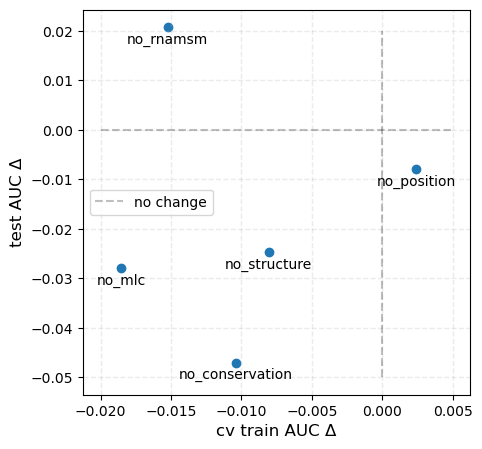

In [120]:
plt.figure(figsize=(5,5))
plt.scatter(
    auc_drop_training_and_test.training,
    auc_drop_training_and_test.test,
)
auc_drop_training_and_test.apply(
    lambda row: plt.text(row.training+.00, row.test-.0025, row.name, ha="center", va="center"),
    axis=1
)
plt.plot([0,0],[-.05,.02],"k--",alpha=.25, label="no change")
plt.plot([-.02,.005],[0,0],"k--",alpha=.25)
plt.xlabel("cv train AUC Δ", fontsize=12)
plt.ylabel("test AUC Δ", fontsize=12)
plt.grid(ls="--",lw=1, alpha=.25)
plt.legend()
plt.savefig("../../../figures/svg/ablation_study_tAPOGEE_training_and_test.svg")
plt.show()